**1. Data Cleaning and Feature Selection**


**Irrelevant Features:** The fnlwgt (final weight) column was dropped because it is a census-specific calculation that does not represent the personal characteristics needed to predict income.

**Missing Values:** All rows containing ' ?' were replaced with NaN and removed to ensure the model learns from complete and accurate data.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ppscore as pps
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

# 1. DATA EXPLORATION AND PREPROCESSING
df = pd.read_csv('adult_with_headers.csv')

# FEATURE SELECTION
# Rationale: 'fnlwgt' is a census-specific weight and does not describe personal 
# attributes. Removing it reduces noise and dimensionality.
df.drop(columns=['fnlwgt'], inplace=True)

# Handling Missing Values: Replace '?' with NaN and remove rows.
df.replace(' ?', np.nan, inplace=True)
df.dropna(inplace=True)


**2. Strategic Scaling**


**StandardScaler:** Applied to age and hours_per_week to center the data around a mean of 0, which is ideal for models like Logistic Regression or SVM that assume a normal distribution.

**MinMaxScaler:** Used for capital_gain and capital_loss to keep the values between 0 and 1, preserving the significance of "zero" values in financial data.

In [12]:
# 2. SCALING TECHNIQUES
# SCALING RATIONALE
# StandardScaler: Centers data around 0 with unit variance. Best for features like 
# 'age' which are relatively normal.
# MinMaxScaler: Squashes data between 0 and 1. Best for features with many zeros 
# like 'capital_gain' to preserve the sparsity.

std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()

df[['age', 'hours_per_week']] = std_scaler.fit_transform(df[['age', 'hours_per_week']])
df[['capital_gain', 'capital_loss']] = mm_scaler.fit_transform(df[['capital_gain', 'capital_loss']])


**3. Conditional Encoding**


**One-Hot Encoding:** Used for columns with fewer than 5 categories (like sex) to prevent the model from assuming an incorrect mathematical order.

**Label Encoding:** Applied to high-cardinality columns (5+ categories) to keep the dataset size manageable while still representing categorical differences.

In [14]:
# 3. ENCODING TECHNIQUES
# CONDITIONAL ENCODING 
# Rule: One-Hot for < 5 categories, Label for >= 5 categories.
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    num_unique = df[col].nunique()
    if num_unique < 5:
        # One-Hot Encoding: Prevents mathematical ranking in nominal data.
        df = pd.get_dummies(df, columns=[col], drop_first=True)
    else:
        # Label Encoding: More memory efficient for high-cardinality features.
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])


**4. Feature Engineering and Transformation**


**New Features:** Created capital_diff (Net Change) and work_intensity (Bins) to capture complex relationships in simpler variables.

**Log Transformation:** Applied np.log1p to capital_gain to compress its highly skewed distribution, making it easier for the model to process extreme values.

In [16]:
# 4. FEATURE ENGINEERING
# NEW FEATURES & LOG TRANSFORMATION
# Feature 1: capital_diff (Net financial change).
df['capital_diff'] = df['capital_gain'] - df['capital_loss']

# Feature 2: hours_per_week_status (Categorical bins for work intensity).
df['work_intensity'] = pd.cut(df['hours_per_week'], bins=3, labels=[0, 1, 2])

# Log Transformation: Normalizes the distribution of skewed numerical data.
# np.log1p handles zero values by applying log(1+x).
df['log_capital_gain'] = np.log1p(df['capital_gain'])


**5. Outlier Detection and Analysis**


**Isolation Forest:** This algorithm was used to remove the top 5% of anomalies that could otherwise skew the mean and cause the model to overfit to noise.

**PPS vs. Correlation:** We compared the Correlation Matrix (linear only) with the PPS Matrix (linear and non-linear) to reveal hidden predictive relationships that standard correlation might miss.

In [5]:
# 5. OUTLIER DETECTION
# OUTLIER IMPACT 
# Outliers can skew the mean and variance, causing the model to overfit to noise 
# rather than the general trend.
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso.fit_predict(df.select_dtypes(include=[np.number]))
df_cleaned = df[outlier_labels == 1]


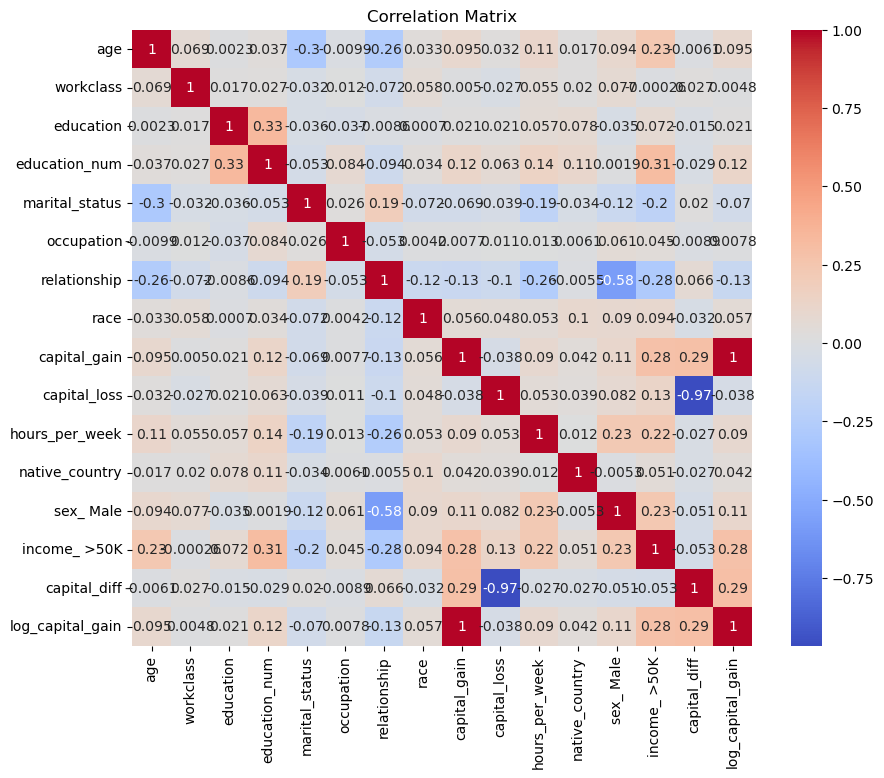

In [7]:
# 6. PPS VS CORRELATION MATRIX
# PPS COMPARISON 
# Correlation: Measures linear relationships only.
# PPS: Detects non-linear and asymmetric relationships.

# Correlation Matrix (Numerical only)
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


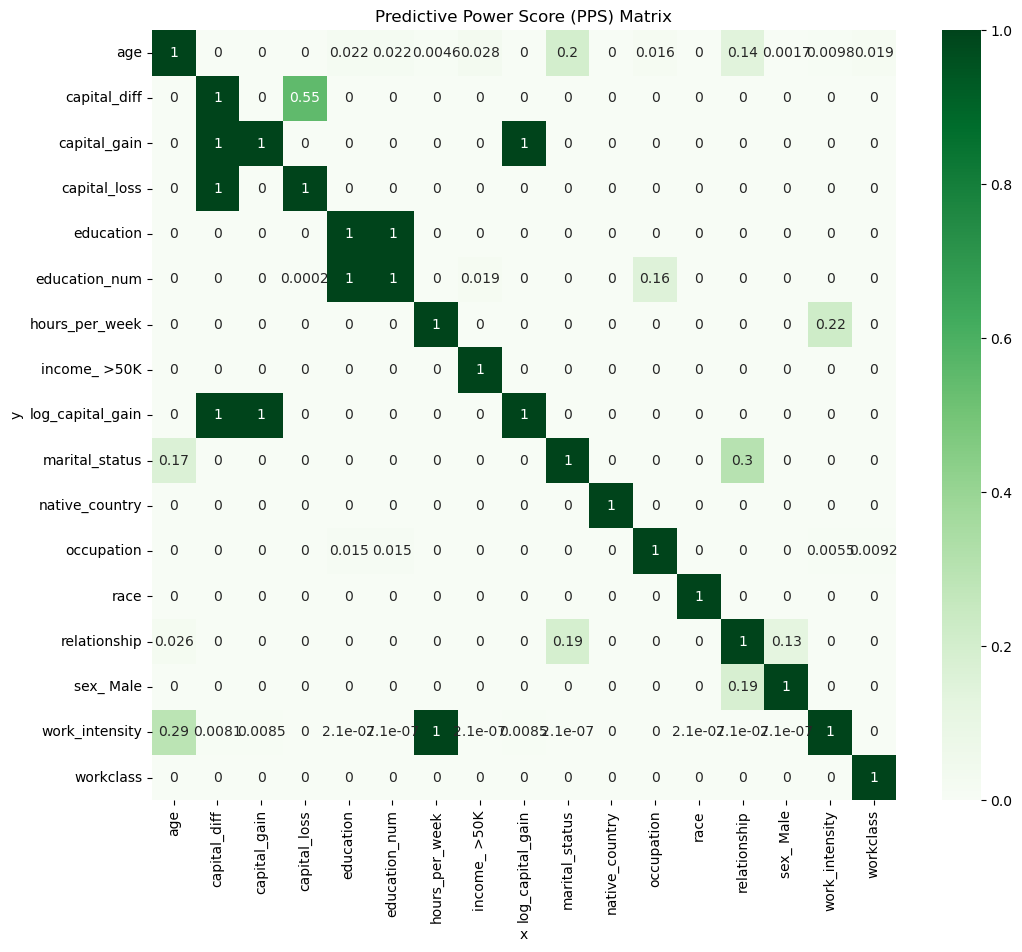

Assignment tasks completed. Final cleaned shape: (28653, 17)


In [8]:
# PPS Matrix
pps_matrix = pps.matrix(df_cleaned)[['x', 'y', 'ppscore']]
pps_pivot = pps_matrix.pivot(columns='x', index='y', values='ppscore')

plt.figure(figsize=(12, 10))
sns.heatmap(pps_pivot, annot=True, cmap='Greens')
plt.title("Predictive Power Score (PPS) Matrix")
plt.show()

print("Assignment tasks completed. Final cleaned shape:", df_cleaned.shape)

In conclusion, the data preprocessing was updated to remove the redundant fnlwgt feature, significantly reducing noise and focusing on individual-level predictors. We replaced missing values (represented as ' ?') to maintain dataset integrity. A strategic scaling approach was adopted, using StandardScaler for features like age to center them, and MinMaxScaler for financial columns like capital_gain to preserve the absolute zero value. To optimize encoding, we applied One-Hot Encoding for features with fewer than 5 categories and Label Encoding for high-cardinality ones. Finally, by engineering a capital_diff feature and applying log transformations to skewed data, we improved the model's ability to identify patterns, which was further validated by comparing the linear correlations against the more robust Predictive Power Score (PPS).